# 04 · Contratos — Exploración Inicial
**Objetivo:** Entender la estructura del portafolio contractual antes de construir indicadores.

**Datos:** `data/pivot_area - Data.csv` (22 columnas)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

DATA_PATH = '../data/pivot_area - Data.csv'
REFERENCE_DATE = pd.Timestamp('2026-05-11')

## 1. Carga y estructura general

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8', sep=None, engine='python')

# Eliminar columna índice sin nombre si existe
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Renombres cortos para trabajo
df.columns = df.columns.str.strip()

print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print()
print('Columnas disponibles:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

Filas:    52,004
Columnas: 21

Columnas disponibles:
   1. Proyecto - Nombre del proyecto
   2. Nombre del propietario
   3. Tipo de contrato
   4. Organización - Departamento
   5. Contrato - ID de contrato
   6. Compañía Contratante / NIT / Representante Legal de la Compañía Contratante / Cédula de Ciudadanía
   7. Fecha de inicio
   8. Contrato - Fecha de entrada en vigor
   9. Contrato - Fecha de expiración
  10. Estado
  11. Estado del contrato
  12. Identificación del proveedor (NIT, Cédula de Ciudadanía, etc)
  13. Partes afectadas - ID de proveedor (L1)
  14. Partes afectadas - Nombre del proveedor (L1)
  15. Administrador de contrato
  16. Tipo de periodo de vigencia
  17. Representante Legal del Proveedor / Cédula de Ciudadanía
  18. Tipo de OTROSÍ
  19. Propietario - Fecha de creación
  20. sum(Importe del contrato)
  21. sum(Importe Valor del OTROSÍ (SIN IVA))


In [3]:
# Primeros registros
df.head(3)

,Proyecto - Nombre del proyecto,Nombre del propietario,Tipo de contrato,Organización - Departamento,Contrato - ID de contrato,Compañía Contratante / NIT / Representante Legal de la Compañía Contratante / Cédula de Ciudadanía,Fecha de inicio,Contrato - Fecha de entrada en vigor,Contrato - Fecha de expiración,Estado,Estado del contrato,"Identificación del proveedor (NIT, Cédula de Ciudadanía, etc)",Partes afectadas - ID de proveedor (L1),Partes afectadas - Nombre del proveedor (L1),Administrador de contrato,Tipo de periodo de vigencia,Representante Legal del Proveedor / Cédula de Ciudadanía,Tipo de OTROSÍ,Propietario - Fecha de creación,sum(Importe del contrato),sum(Importe Valor del OTROSÍ (SIN IVA))
0,27012022 Convenio de Colaboración Empresarial Seguros Ge...,Laura Mosquera Villa,CONTRATO FINANCIERO,Financiero,CW2269406,SEGUROS DE VIDA SURAMERICANA S.A. CON NIT 890.903.790-5,30/8/2022,8/8/2019,8/8/2029,Activo,Publicado,NaN,,,Juliana Zuluaga Peralta,Fijo,NaN,NO APLICA,"jue, 12 jun, 2025","141,447,951.00",NaN
1,202603 TERMINACIÓN CONTRATO ABOGADO EXTERNO,Lina Marcela Cadavid Figueroa,CONTRATO PRESTACIÓN DE SERVICIOS ABOGADOS EXTERNOS,Asuntos Legales,CW2373892,SEGUROS GENERALES SURAMERICANA S.A. CON NIT 890.903.407-9,26/2/2026,26/2/2026,26/2/2026,Activo,Borrador,9005802252,ACM_230686569,COORDINADORA JURIDICA S.A.S,Ana Maria Rodriguez Agudelo,Fijo,NaN,NO APLICA,"lun, 8 jun, 2020","250,000,000.00",NaN
2,202406 REGCN CONTRATO MARCO CABLEADO IDECOL LTDA OTRAS C...,Juan Sebastian Estanislao Sanchez,CONTRATO MARCO DE OBRA,Gestion administrativa,CW2317257,SEGUROS GENERALES SURAMERICANA S.A. CON NIT 890.903.407-9,21/6/2024,16/9/2024,15/9/2025,Finalizado,Cerrado,9000950747,ACM_154439103,IDECOL LTDA,Juan Sebastian Estanislao Sanchez,Fijo,CARLOS FERNANDO LEAL CARDENASS CC 79563633,NO APLICA,"jue, 31 ago, 2023","100,000,000.00",NaN


## 2. Parseo de fechas y creación de columnas base

In [4]:
date_cols = [
    'Fecha de inicio',
    'Contrato - Fecha de entrada en vigor',
    'Contrato - Fecha de expiración',
    'Propietario - Fecha de creación',
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

# Columnas derivadas básicas
df['dias_hasta_vencimiento'] = (df['Contrato - Fecha de expiración'] - REFERENCE_DATE).dt.days
df['duracion_dias'] = (
    df['Contrato - Fecha de expiración'] - df['Contrato - Fecha de entrada en vigor']
).dt.days

print('Fechas parseadas y columnas derivadas creadas.')
print()
print('Rango de fechas de expiración:')
print(f'  Más antigua: {df["Contrato - Fecha de expiración"].min()}')
print(f'  Más reciente: {df["Contrato - Fecha de expiración"].max()}')
print(f'  Nulas: {df["Contrato - Fecha de expiración"].isna().sum()}')

Fechas parseadas y columnas derivadas creadas.

Rango de fechas de expiración:
  Más antigua: 1970-01-01 00:00:00
  Más reciente: 2050-12-31 00:00:00
  Nulas: 14


## 3. Campos categóricos clave

In [5]:
cat_cols = [
    'Estado',
    'Estado del contrato',
    'Tipo de contrato',
    'Organización - Departamento',
    'Tipo de periodo de vigencia',
    'Tipo de OTROSÍ',
]

for col in cat_cols:
    if col in df.columns:
        vc = df[col].value_counts(dropna=False)
        print(f'── {col} ── {len(vc)} valores únicos')
        print(vc.head(10).to_string())
        print()

── Estado ── 2 valores únicos
Estado
Finalizado    29551
Activo        22453

── Estado del contrato ── 6 valores únicos
Estado del contrato
Cerrado                      29596
Publicado                    19009
Borrador                      2250
Vencido                        860
Modificación del borrador      262
Pendiente                       27

── Tipo de contrato ── 57 valores únicos
Tipo de contrato
CONTRATO DE PRESTACIÓN  DE SERVICIOS                                11066
NaN                                                                  6149
CONTRATO DE PRESTACIÓN DE SERVICIOS DE PREVENCIÓN (ARL)              4455
CONTRATO MARCO DE SERVICIOS                                          4387
CONTRATO DE PRESTACIÓN DE SERVICIOS NEGOCIO (PÓLIZA DE SALUD)        3289
CONTRATO DE PRESTACIÓN DE SERVICIOS DE NEGOCIO (CGR - SALUD ARL)     2571
TERMINACIÓN SIN INCUMPLIMIENTO                                       2300
CONTRATO DE PRESTACIÓN DE SERVICIOS (EPS SURA)                       184

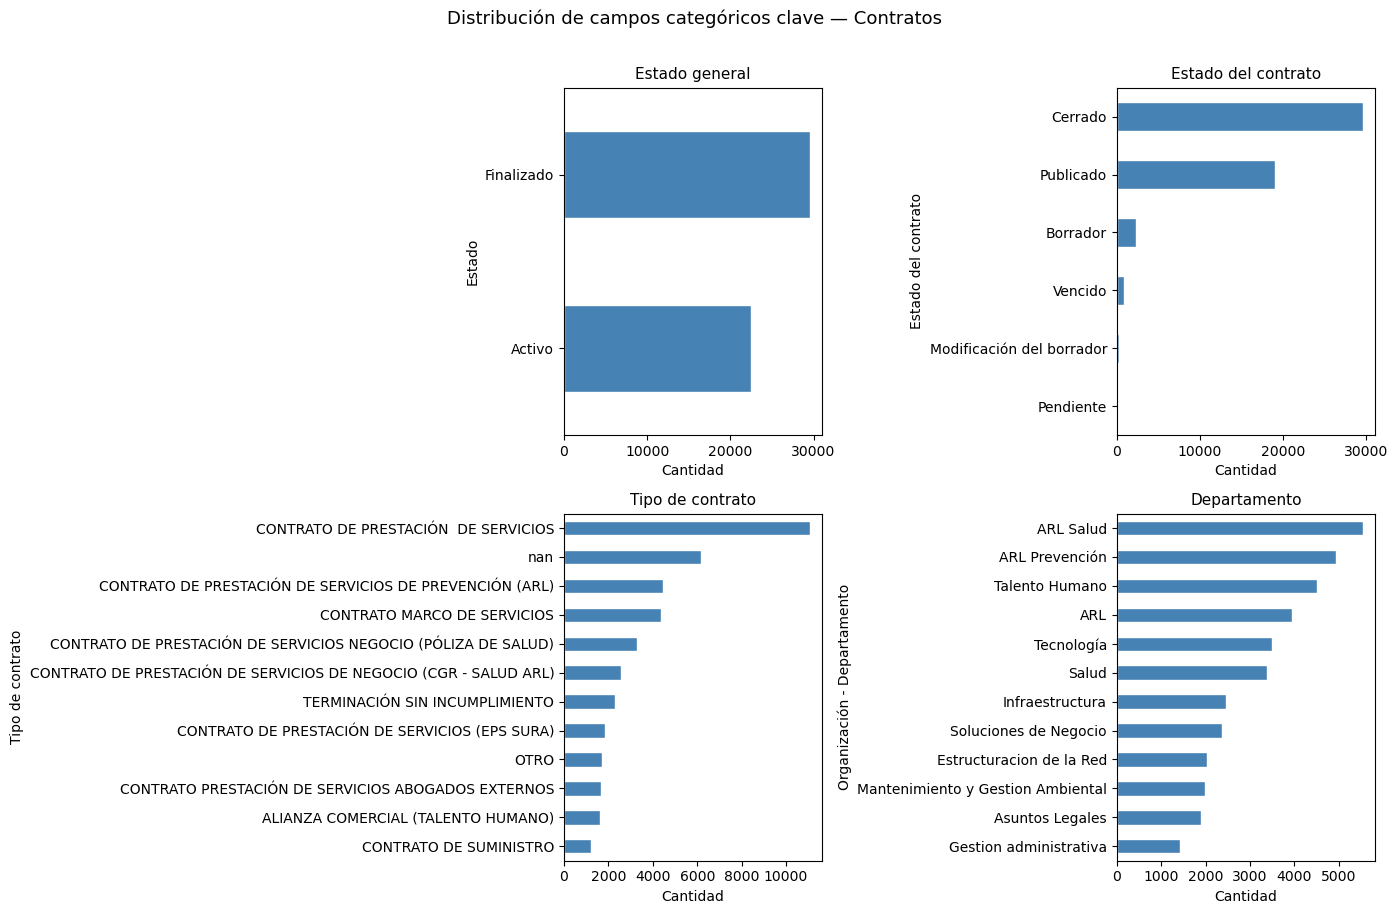

In [6]:
# Distribución visual de los campos más relevantes
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_fields = [
    ('Estado', 'Estado general'),
    ('Estado del contrato', 'Estado del contrato'),
    ('Tipo de contrato', 'Tipo de contrato'),
    ('Organización - Departamento', 'Departamento'),
]

for ax, (col, title) in zip(axes.flat, plot_fields):
    if col in df.columns:
        vc = df[col].value_counts(dropna=False).head(12)
        vc.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Cantidad')
        ax.invert_yaxis()

plt.suptitle('Distribución de campos categóricos clave — Contratos', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Compañías y proveedores

In [7]:
# Compañías contratantes (campo largo — extraer nombre corto)
companias_col = 'Compañía Contratante / NIT / Representante Legal de la Compañía Contratante / Cédula de Ciudadanía'
if companias_col in df.columns:
    print('Top compañías contratantes:')
    print(df[companias_col].value_counts().head(10).to_string())
    print()

proveedor_col = 'Partes afectadas - Nombre del proveedor (L1)'
if proveedor_col in df.columns:
    print('Top proveedores:')
    print(df[proveedor_col].value_counts().head(15).to_string())

Top compañías contratantes:
Compañía Contratante / NIT / Representante Legal de la Compañía Contratante / Cédula de Ciudadanía
SEGUROS DE VIDA SURAMERICANA  S.A. CON NIT 890.903.790-5                      15788
SEGUROS DE VIDA SURAMERICANA  S.A.-RAMO ARL                                    7818
EPS SURAMERICANA S.A. - EPS SURA CON NIT 800.088.702-2                         5340
SEGUROS GENERALES SURAMERICANA S.A. CON NIT 890.903.407-9                      5128
AYUDAS DIAGNOSTICAS SURA S.A.S. CON NIT 800.225.057-8                          3665
SERVICIOS DE SALUD IPS SURAMERICANA S.A.S CON NIT 811.007.832-5                3592
OPERACIONES GENERALES SURAMERICANA S.A.S CON NIT 890.903.279-2                 2704
SERVICIOS GENERALES SURAMERICANA S.A.S CON NIT 811.036.875-5                   1944
CONSULTORIA EN GESTION DE RIESGOS SURAMERICANA S.A.S CON NIT 811.005.246-1     1872
GRUPO DE INVERSIONES SURAMERICANA S.A. CON NIT 811.012.271-3                   1212

Top proveedores:
Partes afectada

## 5. Nulos por columna

In [8]:
nulos = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'pct_nulo': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('pct_nulo', ascending=False)

print('Completitud por columna:')
print(nulos.to_string())

Completitud por columna:
                                                                                                    nulos  pct_nulo
Propietario - Fecha de creación                                                                     52004     100.0
sum(Importe Valor del OTROSÍ (SIN IVA))                                                             40587      78.0
Representante Legal del Proveedor / Cédula de Ciudadanía                                            14991      28.8
Tipo de OTROSÍ                                                                                       7665      14.7
Identificación del proveedor (NIT, Cédula de Ciudadanía, etc)                                        6758      13.0
Tipo de contrato                                                                                     6149      11.8
Administrador de contrato                                                                            3230       6.2
Fecha de inicio                                

## 6. Distribución de vencimientos en el tiempo

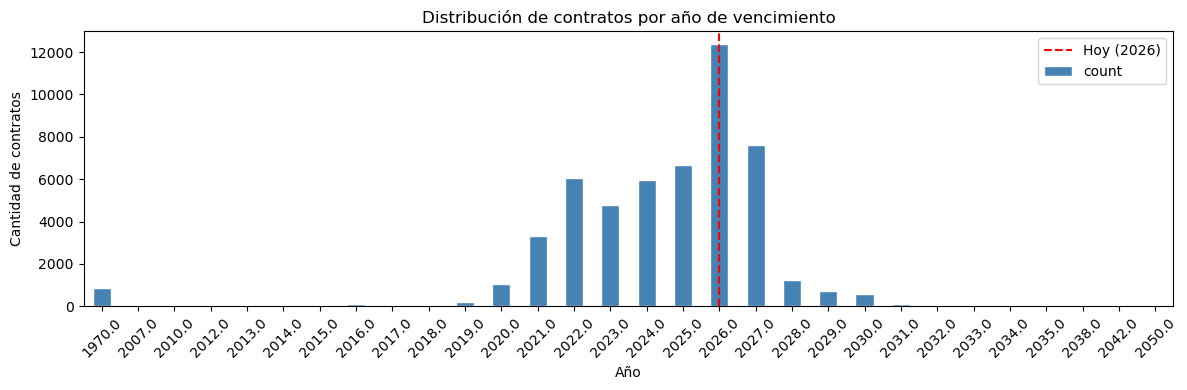

In [9]:
df['año_vencimiento'] = df['Contrato - Fecha de expiración'].dt.year

vc_anio = df['año_vencimiento'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
vc_anio.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(
    list(vc_anio.index).index(REFERENCE_DATE.year) if REFERENCE_DATE.year in vc_anio.index else -1,
    color='red', linestyle='--', linewidth=1.5, label='Hoy (2026)'
)
ax.set_title('Distribución de contratos por año de vencimiento', fontsize=12)
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de contratos')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Resumen de exploración

**Anotar aquí los hallazgos de exploración:**

- Total contratos y rango de vigencias
- Estados presentes y su distribución
- Tipos de contrato más frecuentes
- Compañías/proveedores dominantes
- Campos con alta tasa de nulos

> Continuar en `05_contracts_analysis.ipynb`